In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/Social_Network_Ads.csv")

In [ ]:
df.sample(5)

,Age,EstimatedSalary,Purchased
230,35,147000,1
224,35,60000,0
0,19,19000,0
114,42,80000,0
247,57,122000,1


## Train-test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased", axis=1),
                                                   df['Purchased'],test_size=0.3,
                                                    random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [ ]:
!pip install scikit-learn

## Standard Scaler -
Scaling data from -1 to +1

In [ ]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

#fit the scaler to the training dataset, it will learn the parameters
Scaler.fit(X_train)

#transform train and test datasets
X_train_scaled = Scaler.transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [ ]:
Scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [ ]:
 # sincle testing and training data gets scaled down and converted into array
 #that's why we have converted it to dataframes
 X_train_Scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
 X_test_Scaled = pd.DataFrame(X_train_scaled, columns= X_test.columns)


In [ ]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round (X_train_Scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effect of Scaling

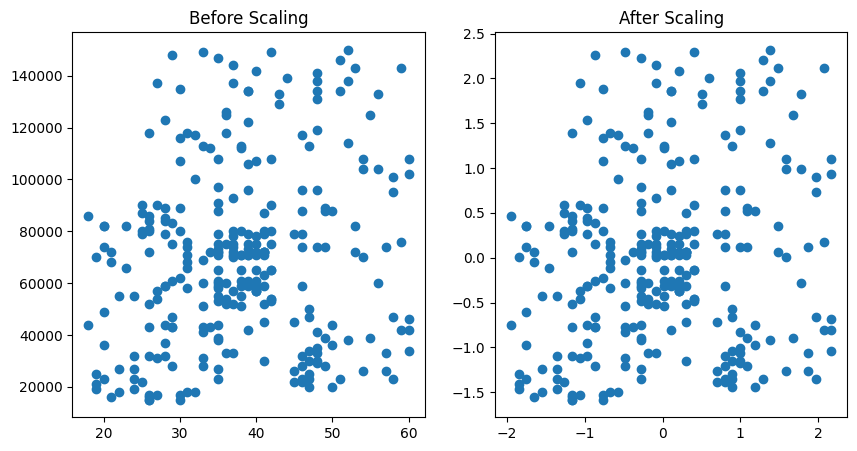

In [ ]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])  #before
ax1.set_title('Before Scaling')
ax2.scatter(X_train_Scaled['Age'],X_train_Scaled['EstimatedSalary']) #after
ax2.set_title('After Scaling')
plt.show()

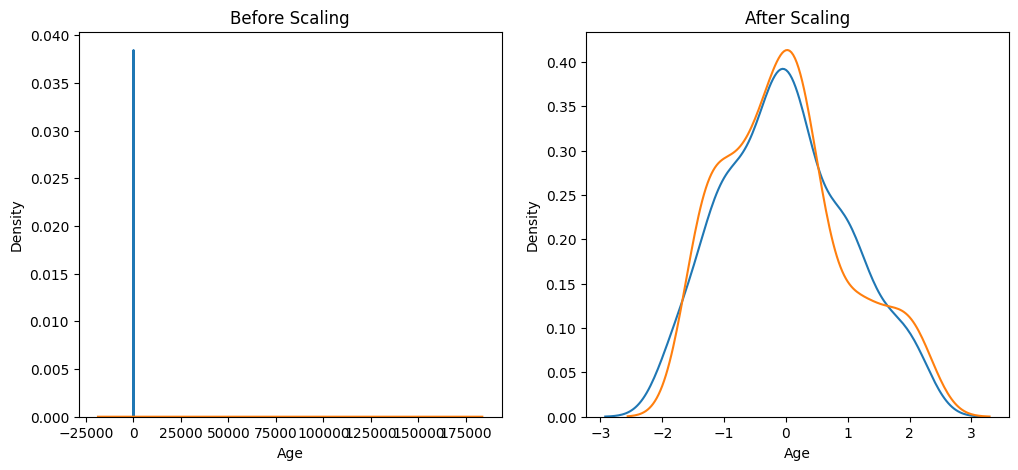

In [ ]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(12,5))

#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#After scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_Scaled['Age'],ax=ax2)
sns.kdeplot(X_train_Scaled['EstimatedSalary'],ax=ax2)
plt.show( )


## Why is Scaling Important?
to improve the accuracy of the model.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:
lr_scaled = LogisticRegression()

In [ ]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667
